
# Minimal 5-record LTST check with dual-channel kernel — patched remote-loading version

This notebook:

- reads LTST records directly from PhysioNet with `pn_dir="ltstdb"`
- avoids the broken `wfdb.dl_files(...)` path that caused 404 errors
- tests **5 records**
- compares:
  - `baseline`
  - `angle`
  - `long`
  - `hybrid`
- evaluates **ST-entry from non-ST beats**
- saves compact summary/detail parquet outputs to Google Drive


In [ ]:

# Setup
!pip -q install wfdb pyarrow fastparquet

import os
import time
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


In [ ]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

# Config
RUN_ID = datetime.now(timezone.utc).strftime("run_%Y%m%dT%H%M%SZ")
DRIVE_ROOT = "/content/drive/MyDrive/ltstdb_minimal_dual_kernel_check"
RUN_ROOT = os.path.join(DRIVE_ROOT, RUN_ID)
os.makedirs(RUN_ROOT, exist_ok=True)

DB = "ltstdb"
BEAT_EXT = "atr"
ST_EXT = "stc"   # change to "stb" if desired

RECORDS = ["s20011", "s20021", "s20031", "s20041", "s20051"]

HORIZONS = [30, 60, 120, 250, 500, 750, 1000]
TOP_N = 1102
CROSSOVER_MIN_DELTA = 0.02

DIM = 9
LAG = 4
MAX_BEAT_OFFSET = 320
MIN_ENERGY_THRESH = 1e-6
ALPHA_SLOW = 0.2
ALPHA_FAST = 0.6

BEAT_WINDOW_PRE = 80
BEAT_WINDOW_POST = 120
LOCAL_TEMPLATE_RADIUS = 10
NORMAL_BEAT_SYMBOLS = {"N"}

SUMMARY_PATH = os.path.join(RUN_ROOT, "summary.parquet")
DETAIL_PATH = os.path.join(RUN_ROOT, "detail.parquet")

print(RUN_ROOT)


/content/drive/MyDrive/ltstdb_minimal_dual_kernel_check/run_20260404T183218Z


In [ ]:

# Helpers
def ensure_single_record_download(record: str, st_ext: str, beat_ext: str = BEAT_EXT):
    # No manual download. Let wfdb stream from PhysioNet directly.
    print(f"Preparing remote access for {record} [{st_ext}] via pn_dir='{DB}'")
    return DB

def cleanup_single_record(record: str):
    # No-op in remote-streaming mode
    return

def save_parquet(df, path):
    tmp = path + ".tmp"
    df.to_parquet(tmp, index=False)
    os.replace(tmp, path)


In [ ]:

# ST parsing
def load_st_intervals(record: str, ext: str, pn_dir: str):
    try:
        ann = wfdb.rdann(record, ext, pn_dir=pn_dir)
    except Exception as e:
        return None, None, f"missing_annotation: {e}"

    samples = np.asarray(ann.sample, dtype=int)
    aux = np.asarray(
        ann.aux_note if getattr(ann, "aux_note", None) is not None else [""] * len(samples),
        dtype=object
    ).astype(str)

    intervals = []
    current_start = None
    found_explicit = False

    for s, note in zip(samples, aux):
        text = (note or "").lower().strip()

        if any(tok in text for tok in ["begin", "start", "onset"]):
            current_start = s
            found_explicit = True
            continue

        if any(tok in text for tok in ["end", "stop", "offset"]):
            if current_start is not None and s > current_start:
                intervals.append((current_start, s))
            current_start = None
            found_explicit = True
            continue

        # LTST-specific patterns
        if ("grst0" in text) or ("lrst0" in text) or ("(rtst0" in text) or ("(rtst1" in text):
            current_start = s
            found_explicit = True
            continue

        if ("grst1" in text) or ("lrst1" in text) or text == ")":
            if current_start is not None and s > current_start:
                intervals.append((current_start, s))
            current_start = None
            found_explicit = True
            continue

    if not found_explicit:
        for i in range(0, len(samples) - 1, 2):
            start, end = samples[i], samples[i + 1]
            if end > start:
                intervals.append((start, end))

    if not intervals:
        return None, None, "no_intervals_parsed"

    durations = [end - start for start, end in intervals]
    diag = {
        "n_intervals": len(intervals),
        "mean_interval_samples": float(np.mean(durations)) if durations else np.nan,
    }
    return intervals, diag, None

def attach_st(df: pd.DataFrame, intervals):
    arr = np.zeros(len(df), dtype=bool)
    epi = np.full(len(df), -1, dtype=int)
    samples = df["beat_sample"].to_numpy(dtype=int)

    for k, (start, end) in enumerate(intervals):
        inside = (samples >= start) & (samples < end)
        arr |= inside
        epi[inside] = k

    df["st_event"] = arr
    df["st_episode_id"] = epi
    return df


In [ ]:

# Dual-channel kernel
FLAG_OK = 0
FLAG_HISTORY_NOT_READY = 0x01
FLAG_RR_OUT_OF_RANGE = 0x02
FLAG_LOW_ENERGY = 0x04

class DualKernel:
    def __init__(self):
        self.state_buffer_size = 1 + MAX_BEAT_OFFSET + (DIM - 1) * LAG
        self.history = np.full(self.state_buffer_size, np.nan, dtype=np.float64)
        self.head_idx = 0
        self.samples_seen = 0
        self.history_ready = False
        self.last_twist_sq = 0.0
        self.last_twist_angle = 0.0
        self.ema_slow = 0.0
        self.ema_fast = 0.0
        self.has_history = False

    def _wrap_index(self, idx):
        idx %= self.state_buffer_size
        if idx < 0:
            idx += self.state_buffer_size
        return idx

    def push(self, voltage):
        self.history[self.head_idx] = float(voltage)
        self.head_idx = (self.head_idx + 1) % self.state_buffer_size
        self.samples_seen += 1
        if self.samples_seen >= self.state_buffer_size:
            self.history_ready = True

    def _get_delayed(self, steps_back):
        return self.history[self._wrap_index(self.head_idx - 1 - steps_back)]

    def compute(self, rr):
        if not self.history_ready:
            return FLAG_HISTORY_NOT_READY, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        if rr <= 0:
            return FLAG_RR_OUT_OF_RANGE, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

        max_needed = rr + (DIM - 1) * LAG
        if max_needed >= self.state_buffer_size:
            return FLAG_RR_OUT_OF_RANGE, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

        x_curr = np.array([self._get_delayed(i * LAG) for i in range(DIM)], dtype=np.float64)
        x_past = np.array([self._get_delayed(rr + i * LAG) for i in range(DIM)], dtype=np.float64)

        sx = sy = sxx = syy = sxy = 0.0
        for vx, vy in zip(x_curr, x_past):
            sx += vx
            sy += vy
            sxx += vx * vx
            syy += vy * vy
            sxy += vx * vy

        invD = 1.0 / float(DIM)
        curr_energy = sxx - (sx * sx) * invD
        past_energy = syy - (sy * sy) * invD
        dot_centered = sxy - (sx * sy) * invD

        if curr_energy < MIN_ENERGY_THRESH or past_energy < MIN_ENERGY_THRESH:
            return FLAG_LOW_ENERGY, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, curr_energy

        prod = curr_energy * past_energy

        twist_angle = 0.0
        if prod > 1e-12:
            cos2 = (dot_centered * dot_centered) / prod
            if cos2 < 0.0:
                cos2 = 0.0
            if cos2 > 1.0:
                cos2 = 1.0
            twist_angle = 2.0 * (1.0 - cos2)

        twist_sq = prod * twist_angle

        drift_centered_sq = curr_energy + past_energy - 2.0 * dot_centered
        if drift_centered_sq < 0.0:
            drift_centered_sq = 0.0

        drift_raw_sq = sxx + syy - 2.0 * sxy
        if drift_raw_sq < 0.0:
            drift_raw_sq = 0.0

        mean_dx = (sx - sy) * invD
        mean_shift_sq = float(DIM) * mean_dx * mean_dx

        if self.has_history:
            raw_slow = twist_sq - self.last_twist_sq
            self.ema_slow = ALPHA_SLOW * raw_slow + (1.0 - ALPHA_SLOW) * self.ema_slow

            raw_fast = twist_angle - self.last_twist_angle
            self.ema_fast = ALPHA_FAST * raw_fast + (1.0 - ALPHA_FAST) * self.ema_fast
        else:
            self.ema_slow = 0.0
            self.ema_fast = 0.0
            self.has_history = True

        self.last_twist_sq = twist_sq
        self.last_twist_angle = twist_angle

        return FLAG_OK, twist_sq, twist_angle, self.ema_slow, self.ema_fast, drift_centered_sq, drift_raw_sq, mean_shift_sq, curr_energy


In [ ]:

# Baseline features
EPS = 1e-12

def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) != len(b) or len(a) == 0:
        return np.nan
    a = a - np.nanmean(a)
    b = b - np.nanmean(b)
    da = np.sqrt(np.nansum(a * a))
    db = np.sqrt(np.nansum(b * b))
    if da < EPS or db < EPS:
        return np.nan
    return float(np.nansum(a * b) / (da * db))

def extract_window(signal, center):
    lo = max(0, int(center) - BEAT_WINDOW_PRE)
    hi = min(len(signal), int(center) + BEAT_WINDOW_POST)
    w = signal[lo:hi]
    target_len = BEAT_WINDOW_PRE + BEAT_WINDOW_POST
    if len(w) < target_len:
        w = np.concatenate([w, np.full(target_len - len(w), np.nan)])
    return w

def add_local_template_features(df, signal):
    windows = [extract_window(signal, bs) for bs in df["beat_sample"].astype(int).values]
    symbols = df["beat_symbol"].astype(str).values

    template_corr = []
    for i, w in enumerate(windows):
        w_num = np.nan_to_num(w, nan=np.nanmean(w) if np.isfinite(np.nanmean(w)) else 0.0)
        lo = max(0, i - LOCAL_TEMPLATE_RADIUS)
        hi = min(len(windows), i + LOCAL_TEMPLATE_RADIUS + 1)
        pool_idx = [j for j in range(lo, hi) if j != i and symbols[j] in NORMAL_BEAT_SYMBOLS]
        if len(pool_idx) >= 3:
            template = np.nanmean(np.vstack([windows[j] for j in pool_idx]), axis=0)
            template_num = np.nan_to_num(template, nan=np.nanmean(template) if np.isfinite(np.nanmean(template)) else 0.0)
            template_corr.append(safe_corr(w_num, template_num))
        else:
            template_corr.append(np.nan)

    out = df.copy()
    out["local_template_corr"] = template_corr
    return out


In [ ]:

# Evaluation
def top_n_indices(score_series, n):
    return set(score_series.sort_values(ascending=False).head(n).index.tolist())

def future_hit_rate(idx_set, target_mask, horizon_beats):
    idx = np.array(sorted(idx_set), dtype=int)
    arr = np.asarray(target_mask, dtype=bool)
    n = len(arr)
    hits = []
    for i in idx:
        lo = i + 1
        hi = min(n, i + horizon_beats + 1)
        hits.append(bool(arr[lo:hi].any()) if lo < hi else False)
    hits = np.array(hits, dtype=bool)
    return int(hits.sum()), float(hits.mean()) if len(hits) else np.nan

def evaluate_record(record):
    rec_dir = ensure_single_record_download(record, ST_EXT, BEAT_EXT)

    print(f"Loading record {record} from {rec_dir}")
    rec = wfdb.rdrecord(record, pn_dir=rec_dir)
    ann = wfdb.rdann(record, BEAT_EXT, pn_dir=rec_dir)

    signal = rec.p_signal[:, 0].astype(np.float64)

    beat_df = pd.DataFrame({
        "beat_sample": np.asarray(ann.sample, dtype=int),
        "beat_symbol": np.asarray(ann.symbol, dtype=object).astype(str),
    }).reset_index(drop=True)
    beat_df["rr_samples"] = beat_df["beat_sample"].diff()
    beat_df.loc[0, "rr_samples"] = np.nan

    kernel = DualKernel()
    beat_lookup = {int(s): i for i, s in enumerate(beat_df["beat_sample"].astype(int).tolist())}

    rows = []
    for sample_idx, v in enumerate(signal):
        kernel.push(v)
        if sample_idx not in beat_lookup:
            continue
        row = beat_df.iloc[beat_lookup[sample_idx]]
        rr = row["rr_samples"]

        if pd.isna(rr):
            vals = (FLAG_RR_OUT_OF_RANGE,) + (np.nan,) * 8
        else:
            vals = kernel.compute(int(rr))

        status, twist_sq, twist_angle, ema_slow, ema_fast, drift_centered_sq, drift_raw_sq, mean_shift_sq, curr_energy = vals

        rows.append({
            "beat_sample": int(row["beat_sample"]),
            "beat_symbol": str(row["beat_symbol"]),
            "rr_samples": rr,
            "status": status,
            "twist_sq": twist_sq,
            "twist_angle": twist_angle,
            "ema_slow": ema_slow,
            "ema_fast": ema_fast,
            "drift_centered_sq": drift_centered_sq,
            "drift_raw_sq": drift_raw_sq,
            "mean_shift_sq": mean_shift_sq,
            "curr_energy": curr_energy,
        })

    df = pd.DataFrame(rows)
    df = df[df["status"] == FLAG_OK].copy().reset_index(drop=True)
    if len(df) == 0:
        raise RuntimeError(f"{record}: no valid kernel rows")

    intervals, diag, err = load_st_intervals(record, ST_EXT, rec_dir)
    if intervals is None:
        raise RuntimeError(f"{record}: {err}")

    df = attach_st(df, intervals)
    df = add_local_template_features(df, signal)

    df["baseline_score"] = 1.0 - df["local_template_corr"].astype(float)
    df["kernel_score_angle"] = df["twist_angle"].clip(lower=0) * df["ema_fast"].clip(lower=0)
    df["kernel_score_long"] = df["twist_sq"].clip(lower=0) * df["ema_slow"].clip(lower=0)

    angle_rank = df["kernel_score_angle"].rank(pct=True, method="average")
    long_rank = df["kernel_score_long"].rank(pct=True, method="average")
    df["kernel_score_hybrid"] = 0.5 * angle_rank + 0.5 * long_rank

    st_bool = df["st_event"].fillna(False).astype(bool)
    st_prev = st_bool.shift(1).fillna(False)
    df["st_entry"] = st_bool & (~st_prev)

    eval_mask = ~df["st_event"].fillna(False).astype(bool)
    if int(eval_mask.sum()) < TOP_N * 2:
        raise RuntimeError(f"{record}: insufficient non-ST beats")

    target = df["st_entry"].to_numpy(dtype=bool)

    methods = {
        "baseline": df.loc[eval_mask, "baseline_score"],
        "angle": df.loc[eval_mask, "kernel_score_angle"],
        "long": df.loc[eval_mask, "kernel_score_long"],
        "hybrid": df.loc[eval_mask, "kernel_score_hybrid"],
    }

    detail_rows = []
    hit_map = {name: {} for name in methods}

    for method_name, score in methods.items():
        idx_set = top_n_indices(score, TOP_N)
        for h in HORIZONS:
            n_hits, hit_rate = future_hit_rate(idx_set, target, h)
            hit_map[method_name][h] = hit_rate
            detail_rows.append({
                "record": record,
                "st_ext": ST_EXT,
                "method": method_name,
                "horizon_beats": h,
                "hit_rate": hit_rate,
                "n_hits": n_hits,
                "n_events": TOP_N,
                "n_st_intervals": int(diag["n_intervals"]),
                "st_prevalence": float(df["st_event"].mean()),
            })

    summary_row = {
        "record": record,
        "st_ext": ST_EXT,
        "n_beats": len(df),
        "n_non_st_beats": int(eval_mask.sum()),
        "n_st_intervals": int(diag["n_intervals"]),
        "st_prevalence": float(df["st_event"].mean()),
        "angle_cross": next((h for h in HORIZONS if hit_map["angle"][h] - hit_map["baseline"][h] > CROSSOVER_MIN_DELTA), None),
        "long_cross": next((h for h in HORIZONS if hit_map["long"][h] - hit_map["baseline"][h] > CROSSOVER_MIN_DELTA), None),
        "hybrid_cross": next((h for h in HORIZONS if hit_map["hybrid"][h] - hit_map["baseline"][h] > CROSSOVER_MIN_DELTA), None),
        "delta_angle_120": hit_map["angle"][120] - hit_map["baseline"][120],
        "delta_long_500": hit_map["long"][500] - hit_map["baseline"][500],
        "delta_long_1000": hit_map["long"][1000] - hit_map["baseline"][1000],
        "delta_hybrid_250": hit_map["hybrid"][250] - hit_map["baseline"][250],
    }

    return pd.DataFrame(detail_rows), summary_row


In [ ]:

# Run the 5-record check
all_detail = []
summary_rows = []
failed = []

for record in RECORDS:
    print(f"RUN {record} ...", flush=True)
    t0 = time.time()
    try:
        detail_df, summary_row = evaluate_record(record)
        all_detail.append(detail_df)
        summary_rows.append(summary_row)
        print(
            f"  OK {record} | angle_cross={summary_row['angle_cross']} "
            f"| long_cross={summary_row['long_cross']} "
            f"| hybrid_cross={summary_row['hybrid_cross']} "
            f"| {round(time.time()-t0,2)}s"
        )
    except Exception as e:
        failed.append({"record": record, "reason": str(e)})
        print(f"  FAIL {record}: {e}")
    finally:
        cleanup_single_record(record)

detail_all = pd.concat(all_detail, ignore_index=True) if all_detail else pd.DataFrame()
summary_df = pd.DataFrame(summary_rows)
failed_df = pd.DataFrame(failed)

if len(detail_all):
    save_parquet(detail_all, DETAIL_PATH)
if len(summary_df):
    save_parquet(summary_df, SUMMARY_PATH)

print()
print("Summary path:", SUMMARY_PATH)
print("Detail path :", DETAIL_PATH)
display(summary_df)
if len(failed_df):
    display(failed_df)


RUN s20011 ...
Preparing remote access for s20011 [stc] via pn_dir='ltstdb'
Loading record s20011 from ltstdb
  OK s20011 | angle_cross=500 | long_cross=250 | hybrid_cross=250 | 339.32s
RUN s20021 ...
Preparing remote access for s20021 [stc] via pn_dir='ltstdb'
Loading record s20021 from ltstdb
  OK s20021 | angle_cross=250 | long_cross=None | hybrid_cross=None | 302.73s
RUN s20031 ...
Preparing remote access for s20031 [stc] via pn_dir='ltstdb'
Loading record s20031 from ltstdb
  OK s20031 | angle_cross=120 | long_cross=120 | hybrid_cross=120 | 344.24s
RUN s20041 ...
Preparing remote access for s20041 [stc] via pn_dir='ltstdb'
Loading record s20041 from ltstdb
  OK s20041 | angle_cross=None | long_cross=60 | hybrid_cross=250 | 353.13s
RUN s20051 ...
Preparing remote access for s20051 [stc] via pn_dir='ltstdb'
Loading record s20051 from ltstdb
  OK s20051 | angle_cross=None | long_cross=120 | hybrid_cross=250 | 332.6s

Summary path: /content/drive/MyDrive/ltstdb_minimal_dual_kernel_che

,record,st_ext,n_beats,n_non_st_beats,n_st_intervals,st_prevalence,angle_cross,long_cross,hybrid_cross,delta_angle_120,delta_long_500,delta_long_1000,delta_hybrid_250
0,s20011,stc,100049,82257,39,0.177833,500.0,250.0,250.0,0.005445,0.055354,0.107078,0.024501
1,s20021,stc,88920,65111,138,0.267758,250.0,NaN,NaN,0.002722,-0.116152,-0.074410,-0.119782
2,s20031,stc,109434,86173,27,0.212557,120.0,120.0,120.0,0.022686,0.071688,0.097096,0.034483
3,s20041,stc,109075,90619,70,0.169205,NaN,60.0,250.0,-0.012704,0.120690,0.132486,0.032668
4,s20051,stc,112885,99087,81,0.122231,NaN,120.0,250.0,-0.084392,0.030853,0.026316,0.038113


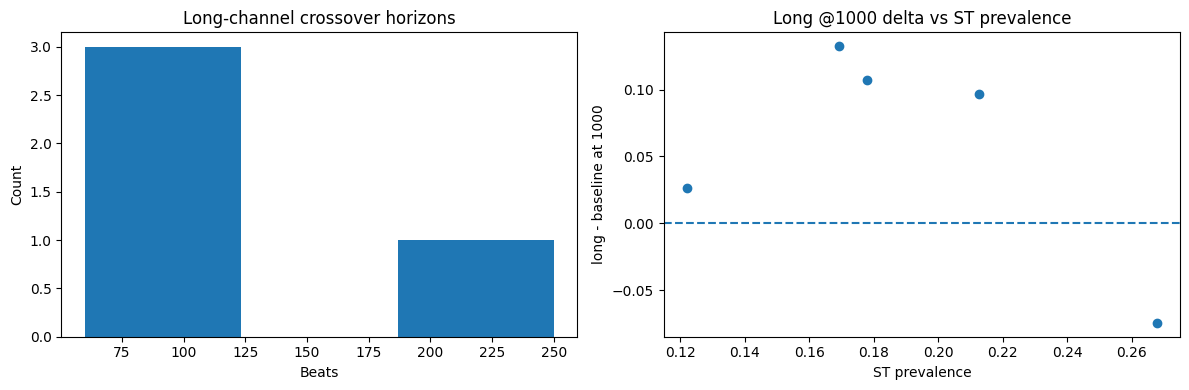

method,record,horizon_beats,angle,baseline,hybrid,long
0,s20011,30,0.006352,0.004537,0.009982,0.009074
1,s20011,60,0.009982,0.007260,0.012704,0.014519
2,s20011,120,0.023593,0.018149,0.032668,0.032668
3,s20011,250,0.065336,0.045372,0.069873,0.069873
4,s20011,500,0.137931,0.081670,0.136116,0.137024
5,s20011,750,0.189655,0.102541,0.193285,0.188748
6,s20011,1000,0.236842,0.131579,0.243194,0.238657
7,s20021,30,0.084392,0.082577,0.047187,0.066243
8,s20021,60,0.140653,0.151543,0.079855,0.118875
9,s20021,120,0.235027,0.232305,0.139746,0.174229


In [ ]:

# Quick plots
if len(summary_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    vals = summary_df["long_cross"].dropna()
    if len(vals):
        axes[0].hist(vals, bins=min(10, len(np.unique(vals))))
    axes[0].set_title("Long-channel crossover horizons")
    axes[0].set_xlabel("Beats")
    axes[0].set_ylabel("Count")

    axes[1].scatter(summary_df["st_prevalence"], summary_df["delta_long_1000"])
    axes[1].axhline(0.0, linestyle="--")
    axes[1].set_title("Long @1000 delta vs ST prevalence")
    axes[1].set_xlabel("ST prevalence")
    axes[1].set_ylabel("long - baseline at 1000")

    plt.tight_layout()
    plt.show()

if len(detail_all):
    pivot = detail_all.pivot_table(index=["record", "horizon_beats"], columns="method", values="hit_rate").reset_index()
    display(pivot.head(30))


In [ ]:
# Post-run regime table linking crossovers to the new invariants

import numpy as np
import pandas as pd

if "summary_df" not in globals():
    raise RuntimeError("summary_df not found. Run the 5-record panel first.")

print("Current crossover table:")
display(summary_df[[
    "record", "angle_cross", "long_cross", "hybrid_cross",
    "delta_angle_120", "delta_long_500", "delta_long_1000", "delta_hybrid_250"
]].copy())

def classify_regime(row):
    a = row["angle_cross"]
    l = row["long_cross"]
    h = row["hybrid_cross"]

    if pd.notna(a) and pd.isna(l):
        return "angle_only"
    if pd.isna(a) and pd.notna(l):
        return "long_only"
    if pd.notna(a) and pd.notna(l):
        if a < l:
            return "angle_first"
        elif l < a:
            return "long_first"
        else:
            return "both_same_horizon"
    return "neither"

regime_df = summary_df.copy()
regime_df["regime"] = regime_df.apply(classify_regime, axis=1)

print("\nRegime classification:")
display(regime_df[[
    "record", "regime", "angle_cross", "long_cross", "hybrid_cross",
    "delta_angle_120", "delta_long_500", "delta_long_1000", "delta_hybrid_250",
    "st_prevalence", "n_st_intervals"
]].sort_values(["regime", "record"]).reset_index(drop=True))

print("\nRegime counts:")
display(regime_df["regime"].value_counts(dropna=False).rename_axis("regime").reset_index(name="count"))

# ------------------------------------------------------------
# Optional invariant linkage block
# This works only if you have / later add a beat-level dataframe
# with columns like:
#   record, phase_polarity, poincare_b, energy_asym, drift_norm
# ------------------------------------------------------------

beat_level_name = None
for candidate in ["beat_level_df", "per_beat_df", "df_kernel_all", "invariant_feature_df"]:
    if candidate in globals() and isinstance(globals()[candidate], pd.DataFrame):
        if "record" in globals()[candidate].columns:
            beat_level_name = candidate
            break

if beat_level_name is None:
    print("\nNo multi-record beat-level invariant dataframe found.")
    print("When you add/store beat-level columns (phase_polarity, poincare_b, energy_asym, drift_norm),")
    print("rerun this cell to link regimes back to the invariants.")
else:
    beats = globals()[beat_level_name].copy()
    needed_cols = {"record", "phase_polarity", "poincare_b", "energy_asym", "drift_norm"}
    missing = needed_cols - set(beats.columns)

    if missing:
        print(f"\nBeat-level dataframe '{beat_level_name}' is missing columns: {missing}")
    else:
        inv_summary = (
            beats.groupby("record")
            .agg(
                median_phase_polarity=("phase_polarity", "median"),
                frac_negative_phase=("phase_polarity", lambda s: np.mean(pd.Series(s).fillna(1.0) < 0)),
                poincare_b_p05=("poincare_b", lambda s: np.nanpercentile(s, 5)),
                poincare_b_p50=("poincare_b", lambda s: np.nanpercentile(s, 50)),
                poincare_b_p95=("poincare_b", lambda s: np.nanpercentile(s, 95)),
                median_energy_asym=("energy_asym", "median"),
                p10_energy_asym=("energy_asym", lambda s: np.nanpercentile(s, 10)),
                p90_energy_asym=("energy_asym", lambda s: np.nanpercentile(s, 90)),
                median_drift_norm=("drift_norm", "median"),
                p90_drift_norm=("drift_norm", lambda s: np.nanpercentile(s, 90)),
            )
            .reset_index()
        )

        linked = regime_df.merge(inv_summary, on="record", how="left")

        print("\nRegime table linked to invariants:")
        display(linked[[
            "record", "regime", "angle_cross", "long_cross", "hybrid_cross",
            "median_phase_polarity", "frac_negative_phase",
            "poincare_b_p05", "poincare_b_p50", "poincare_b_p95",
            "median_energy_asym", "p10_energy_asym", "p90_energy_asym",
            "median_drift_norm", "p90_drift_norm"
        ]].sort_values(["regime", "record"]).reset_index(drop=True))

        print("\nHeuristic reading guide:")
        print("- angle-dominant records may show more negative/volatile poincare_b or more sign flips")
        print("- long-dominant records may show larger drift_norm / energy asymmetry structure")
        print("- mixed records may need gated routing instead of simple hybrid averaging")

globals()["regime_df"] = regime_df
print("\nSaved: regime_df")

Current crossover table:


,record,angle_cross,long_cross,hybrid_cross,delta_angle_120,delta_long_500,delta_long_1000,delta_hybrid_250
0,s20011,500.0,250.0,250.0,0.005445,0.055354,0.107078,0.024501
1,s20021,250.0,NaN,NaN,0.002722,-0.116152,-0.074410,-0.119782
2,s20031,120.0,120.0,120.0,0.022686,0.071688,0.097096,0.034483
3,s20041,NaN,60.0,250.0,-0.012704,0.120690,0.132486,0.032668
4,s20051,NaN,120.0,250.0,-0.084392,0.030853,0.026316,0.038113



Regime classification:


,record,regime,angle_cross,long_cross,hybrid_cross,delta_angle_120,delta_long_500,delta_long_1000,delta_hybrid_250,st_prevalence,n_st_intervals
0,s20021,angle_only,250.0,NaN,NaN,0.002722,-0.116152,-0.074410,-0.119782,0.267758,138
1,s20031,both_same_horizon,120.0,120.0,120.0,0.022686,0.071688,0.097096,0.034483,0.212557,27
2,s20011,long_first,500.0,250.0,250.0,0.005445,0.055354,0.107078,0.024501,0.177833,39
3,s20041,long_only,NaN,60.0,250.0,-0.012704,0.120690,0.132486,0.032668,0.169205,70
4,s20051,long_only,NaN,120.0,250.0,-0.084392,0.030853,0.026316,0.038113,0.122231,81



Regime counts:


,regime,count
0,long_only,2
1,long_first,1
2,angle_only,1
3,both_same_horizon,1



No multi-record beat-level invariant dataframe found.
When you add/store beat-level columns (phase_polarity, poincare_b, energy_asym, drift_norm),
rerun this cell to link regimes back to the invariants.

Saved: regime_df


In [ ]:
# Next cell: build beat-level invariants and test a simple routed rule

import numpy as np
import pandas as pd
import wfdb

EPS = 1e-12

def top_n_indices(score_series, n):
    return set(score_series.sort_values(ascending=False).head(n).index.tolist())

def future_hit_rate(idx_set, target_mask, horizon_beats):
    idx = np.array(sorted(idx_set), dtype=int)
    arr = np.asarray(target_mask, dtype=bool)
    n = len(arr)
    hits = []
    for i in idx:
        lo = i + 1
        hi = min(n, i + horizon_beats + 1)
        hits.append(bool(arr[lo:hi].any()) if lo < hi else False)
    hits = np.array(hits, dtype=bool)
    return int(hits.sum()), float(hits.mean()) if len(hits) else np.nan

def build_beat_level_with_invariants(record):
    rec_dir = ensure_single_record_download(record, ST_EXT, BEAT_EXT)

    rec = wfdb.rdrecord(record, pn_dir=rec_dir)
    ann = wfdb.rdann(record, BEAT_EXT, pn_dir=rec_dir)
    signal = rec.p_signal[:, 0].astype(np.float64)

    beat_df = pd.DataFrame({
        "beat_sample": np.asarray(ann.sample, dtype=int),
        "beat_symbol": np.asarray(ann.symbol, dtype=object).astype(str),
    }).reset_index(drop=True)
    beat_df["rr_samples"] = beat_df["beat_sample"].diff()
    beat_df.loc[0, "rr_samples"] = np.nan

    # Local kernel with extra internal invariants exposed
    state_buffer_size = 1 + MAX_BEAT_OFFSET + (DIM - 1) * LAG
    history = np.full(state_buffer_size, np.nan, dtype=np.float64)
    head_idx = 0
    samples_seen = 0
    history_ready = False

    last_twist_sq = 0.0
    last_twist_angle = 0.0
    ema_slow = 0.0
    ema_fast = 0.0
    has_history = False

    def wrap_index(idx):
        idx %= state_buffer_size
        if idx < 0:
            idx += state_buffer_size
        return idx

    def push(v):
        nonlocal head_idx, samples_seen, history_ready
        history[head_idx] = float(v)
        head_idx = (head_idx + 1) % state_buffer_size
        samples_seen += 1
        if samples_seen >= state_buffer_size:
            history_ready = True

    def get_delayed(steps_back):
        return history[wrap_index(head_idx - 1 - steps_back)]

    beat_lookup = {int(s): i for i, s in enumerate(beat_df["beat_sample"].astype(int).tolist())}
    rows = []

    for sample_idx, v in enumerate(signal):
        push(v)
        if sample_idx not in beat_lookup:
            continue

        row = beat_df.iloc[beat_lookup[sample_idx]]
        rr = row["rr_samples"]

        if (not history_ready) or pd.isna(rr) or rr <= 0 or (int(rr) + (DIM - 1) * LAG >= state_buffer_size):
            rows.append({
                "record": record,
                "beat_sample": int(row["beat_sample"]),
                "beat_symbol": str(row["beat_symbol"]),
                "rr_samples": rr,
                "status": FLAG_RR_OUT_OF_RANGE,
            })
            continue

        x_curr = np.array([get_delayed(i * LAG) for i in range(DIM)], dtype=np.float64)
        x_past = np.array([get_delayed(int(rr) + i * LAG) for i in range(DIM)], dtype=np.float64)

        sx = sy = sxx = syy = sxy = 0.0
        for vx, vy in zip(x_curr, x_past):
            sx += vx
            sy += vy
            sxx += vx * vx
            syy += vy * vy
            sxy += vx * vy

        invD = 1.0 / float(DIM)
        curr_energy = sxx - (sx * sx) * invD
        past_energy = syy - (sy * sy) * invD
        dot_centered = sxy - (sx * sy) * invD

        if curr_energy < MIN_ENERGY_THRESH or past_energy < MIN_ENERGY_THRESH:
            rows.append({
                "record": record,
                "beat_sample": int(row["beat_sample"]),
                "beat_symbol": str(row["beat_symbol"]),
                "rr_samples": rr,
                "status": FLAG_LOW_ENERGY,
                "curr_energy": curr_energy,
                "past_energy": past_energy,
                "dot_centered": dot_centered,
            })
            continue

        prod = curr_energy * past_energy

        cos2 = 0.0
        cos_signed = np.nan
        if prod > EPS:
            cos2 = (dot_centered * dot_centered) / prod
            cos2 = min(max(cos2, 0.0), 1.0)
            cos_signed = dot_centered / np.sqrt(prod)

        twist_angle = 2.0 * (1.0 - cos2)
        twist_sq = prod * twist_angle

        drift_centered_sq = curr_energy + past_energy - 2.0 * dot_centered
        drift_centered_sq = max(drift_centered_sq, 0.0)

        drift_raw_sq = sxx + syy - 2.0 * sxy
        drift_raw_sq = max(drift_raw_sq, 0.0)

        mean_dx = (sx - sy) * invD
        mean_shift_sq = float(DIM) * mean_dx * mean_dx

        if has_history:
            raw_slow = twist_sq - last_twist_sq
            ema_slow = ALPHA_SLOW * raw_slow + (1.0 - ALPHA_SLOW) * ema_slow

            raw_fast = twist_angle - last_twist_angle
            ema_fast = ALPHA_FAST * raw_fast + (1.0 - ALPHA_FAST) * ema_fast
        else:
            ema_slow = 0.0
            ema_fast = 0.0
            has_history = True

        last_twist_sq = twist_sq
        last_twist_angle = twist_angle

        total_energy = curr_energy + past_energy
        energy_delta = curr_energy - past_energy
        energy_asym = energy_delta / total_energy if total_energy > EPS else np.nan
        drift_norm = drift_centered_sq / total_energy if total_energy > EPS else np.nan
        phase_polarity = 1.0 if dot_centered >= 0.0 else -1.0
        poincare_b = dot_centered / curr_energy if curr_energy > EPS else np.nan
        gram_spread_sq = energy_delta * energy_delta + 4.0 * dot_centered * dot_centered

        rows.append({
            "record": record,
            "beat_sample": int(row["beat_sample"]),
            "beat_symbol": str(row["beat_symbol"]),
            "rr_samples": rr,
            "status": FLAG_OK,
            "curr_energy": curr_energy,
            "past_energy": past_energy,
            "dot_centered": dot_centered,
            "twist_angle": twist_angle,
            "twist_sq": twist_sq,
            "ema_fast": ema_fast,
            "ema_slow": ema_slow,
            "drift_centered_sq": drift_centered_sq,
            "drift_raw_sq": drift_raw_sq,
            "mean_shift_sq": mean_shift_sq,
            "phase_polarity": phase_polarity,
            "energy_delta": energy_delta,
            "energy_asym": energy_asym,
            "drift_norm": drift_norm,
            "poincare_b": poincare_b,
            "gram_spread_sq": gram_spread_sq,
            "cos_signed": cos_signed,
        })

    df = pd.DataFrame(rows)
    df = df[df["status"] == FLAG_OK].copy().reset_index(drop=True)
    if len(df) == 0:
        raise RuntimeError(f"{record}: no valid beat-level rows")

    intervals, diag, err = load_st_intervals(record, ST_EXT, rec_dir)
    if intervals is None:
        raise RuntimeError(f"{record}: {err}")

    df = attach_st(df, intervals)
    df = add_local_template_features(df, signal)

    df["baseline_score"] = 1.0 - df["local_template_corr"].astype(float)
    df["kernel_score_angle"] = df["twist_angle"].clip(lower=0) * df["ema_fast"].clip(lower=0)
    df["kernel_score_long"] = df["twist_sq"].clip(lower=0) * df["ema_slow"].clip(lower=0)

    st_bool = df["st_event"].fillna(False).astype(bool)
    st_prev = st_bool.shift(1).fillna(False)
    df["st_entry"] = st_bool & (~st_prev)
    return df

beat_level_frames = []
route_rows = []
inv_rows = []

for record in RECORDS:
    print(f"Building beat-level invariants for {record} ...")
    try:
        dfb = build_beat_level_with_invariants(record)
        beat_level_frames.append(dfb)

        eval_mask = ~dfb["st_event"].fillna(False).astype(bool)
        if int(eval_mask.sum()) < TOP_N * 2:
            print(f"  skip {record}: insufficient non-ST beats")
            continue

        target = dfb["st_entry"].to_numpy(dtype=bool)

        baseline_score = dfb.loc[eval_mask, "baseline_score"]
        angle_score = dfb.loc[eval_mask, "kernel_score_angle"]
        long_score = dfb.loc[eval_mask, "kernel_score_long"]

        # Very simple routed rule:
        # trust angle when signed-instability is strong, otherwise trust long
        route_flag = (
            (dfb.loc[eval_mask, "phase_polarity"] < 0) |
            (dfb.loc[eval_mask, "poincare_b"] < 0.0)
        )

        routed_score = long_score.copy()
        routed_score.loc[route_flag] = angle_score.loc[route_flag]

        methods = {
            "baseline": baseline_score,
            "angle": angle_score,
            "long": long_score,
            "routed": routed_score,
        }

        hit_map = {m: {} for m in methods}
        for method_name, score in methods.items():
            idx_set = top_n_indices(score, TOP_N)
            for h in HORIZONS:
                n_hits, hit_rate = future_hit_rate(idx_set, target, h)
                hit_map[method_name][h] = hit_rate
                route_rows.append({
                    "record": record,
                    "method": method_name,
                    "horizon_beats": h,
                    "hit_rate": hit_rate,
                    "n_hits": n_hits,
                    "n_events": TOP_N,
                })

        inv_rows.append({
            "record": record,
            "frac_negative_phase": float((dfb["phase_polarity"] < 0).mean()),
            "poincare_b_p05": float(np.nanpercentile(dfb["poincare_b"], 5)),
            "poincare_b_p50": float(np.nanpercentile(dfb["poincare_b"], 50)),
            "poincare_b_p95": float(np.nanpercentile(dfb["poincare_b"], 95)),
            "median_energy_asym": float(np.nanmedian(dfb["energy_asym"])),
            "p10_energy_asym": float(np.nanpercentile(dfb["energy_asym"], 10)),
            "p90_energy_asym": float(np.nanpercentile(dfb["energy_asym"], 90)),
            "median_drift_norm": float(np.nanmedian(dfb["drift_norm"])),
            "p90_drift_norm": float(np.nanpercentile(dfb["drift_norm"], 90)),
            "median_gram_spread_sq": float(np.nanmedian(dfb["gram_spread_sq"])),
        })

        print(
            f"  routed@250={hit_map['routed'][250]:.3f} "
            f"baseline@250={hit_map['baseline'][250]:.3f} "
            f"angle@250={hit_map['angle'][250]:.3f} "
            f"long@250={hit_map['long'][250]:.3f}"
        )

    except Exception as e:
        print(f"  FAIL {record}: {e}")

beat_level_df = pd.concat(beat_level_frames, ignore_index=True) if beat_level_frames else pd.DataFrame()
route_df = pd.DataFrame(route_rows)
inv_summary_df = pd.DataFrame(inv_rows)

print("\nBeat-level invariant summary by record:")
display(inv_summary_df.sort_values("record").reset_index(drop=True))

if len(route_df):
    pivot = route_df.pivot_table(index=["record", "horizon_beats"], columns="method", values="hit_rate").reset_index()
    pivot["routed_minus_baseline"] = pivot["routed"] - pivot["baseline"]
    pivot["routed_minus_long"] = pivot["routed"] - pivot["long"]
    pivot["routed_minus_angle"] = pivot["routed"] - pivot["angle"]

    print("\nRouted-rule comparison:")
    display(pivot.sort_values(["record", "horizon_beats"]).reset_index(drop=True))

    route_summary = (
        pivot.groupby("record")
        .agg(
            best_routed_gain_over_baseline=("routed_minus_baseline", "max"),
            best_routed_gain_over_long=("routed_minus_long", "max"),
            best_routed_gain_over_angle=("routed_minus_angle", "max"),
        )
        .reset_index()
    )

    print("\nRouted-rule per-record gains:")
    display(route_summary.sort_values("record").reset_index(drop=True))

globals()["beat_level_df"] = beat_level_df
globals()["route_df"] = route_df
globals()["inv_summary_df"] = inv_summary_df
print("\nSaved globals: beat_level_df, route_df, inv_summary_df")

Building beat-level invariants for s20011 ...
Preparing remote access for s20011 [stc] via pn_dir='ltstdb'
  routed@250=0.070 baseline@250=0.045 angle@250=0.065 long@250=0.070
Building beat-level invariants for s20021 ...
Preparing remote access for s20021 [stc] via pn_dir='ltstdb'
  routed@250=0.365 baseline@250=0.364 angle@250=0.395 long@250=0.285
Building beat-level invariants for s20031 ...
Preparing remote access for s20031 [stc] via pn_dir='ltstdb'
  routed@250=0.062 baseline@250=0.017 angle@250=0.053 long@250=0.062
Building beat-level invariants for s20041 ...
Preparing remote access for s20041 [stc] via pn_dir='ltstdb'
  routed@250=0.265 baseline@250=0.155 angle@250=0.133 long@250=0.240
Building beat-level invariants for s20051 ...
Preparing remote access for s20051 [stc] via pn_dir='ltstdb'
  routed@250=0.175 baseline@250=0.260 angle@250=0.145 long@250=0.326

Beat-level invariant summary by record:


,record,frac_negative_phase,poincare_b_p05,poincare_b_p50,poincare_b_p95,median_energy_asym,p10_energy_asym,p90_energy_asym,median_drift_norm,p90_drift_norm,median_gram_spread_sq
0,s20011,0.000020,0.804589,0.996792,1.189993,-0.000257,-0.149096,0.149168,0.009435,0.044600,67.923893
1,s20021,0.011898,0.336938,0.859895,1.238353,0.003147,-0.264326,0.258378,0.122868,0.501013,0.058831
2,s20031,0.000009,0.759650,0.957410,1.072349,-0.000433,-0.083585,0.084974,0.034243,0.162388,17.859369
3,s20041,0.008490,0.639340,0.974153,1.125428,-0.000662,-0.116400,0.116885,0.017506,0.196139,62.177484
4,s20051,0.089135,-0.293619,0.950268,1.307306,0.000491,-0.261805,0.256504,0.041510,0.784633,1.203623



Routed-rule comparison:


method,record,horizon_beats,angle,baseline,long,routed,routed_minus_baseline,routed_minus_long,routed_minus_angle
0,s20011,30,0.006352,0.004537,0.009074,0.009074,0.004537,0.000000,0.002722
1,s20011,60,0.009982,0.007260,0.014519,0.014519,0.007260,0.000000,0.004537
2,s20011,120,0.023593,0.018149,0.032668,0.032668,0.014519,0.000000,0.009074
3,s20011,250,0.065336,0.045372,0.069873,0.069873,0.024501,0.000000,0.004537
4,s20011,500,0.137931,0.081670,0.137024,0.137024,0.055354,0.000000,-0.000907
5,s20011,750,0.189655,0.102541,0.188748,0.188748,0.086207,0.000000,-0.000907
6,s20011,1000,0.236842,0.131579,0.238657,0.238657,0.107078,0.000000,0.001815
7,s20021,30,0.084392,0.082577,0.066243,0.083485,0.000907,0.017241,-0.000907
8,s20021,60,0.140653,0.151543,0.118875,0.151543,0.000000,0.032668,0.010889
9,s20021,120,0.235027,0.232305,0.174229,0.229583,-0.002722,0.055354,-0.005445



Routed-rule per-record gains:


,record,best_routed_gain_over_baseline,best_routed_gain_over_long,best_routed_gain_over_angle
0,s20011,0.107078,0.000000,0.009074
1,s20021,0.003630,0.108893,0.010889
2,s20031,0.097096,0.000000,0.009074
3,s20041,0.182396,0.041742,0.245917
4,s20051,-0.019056,-0.016334,0.084392



Saved globals: beat_level_df, route_df, inv_summary_df


In [ ]:
# Next cell: guarded 3-regime router
#
# Goal:
# - default to LONG
# - use ANGLE only in structural-shear regimes
# - block ANGLE when chaotic signed dynamics are present
#
# Uses existing globals from the prior cell:
#   beat_level_df, route_df, inv_summary_df

import numpy as np
import pandas as pd

if "beat_level_df" not in globals():
    raise RuntimeError("beat_level_df not found. Run the previous invariant-routing cell first.")

EPS = 1e-12

# -----------------------------
# Tunable guard thresholds
# -----------------------------
# Chaos guard: if any of these fire, do NOT trust angle
CHAOS_NEG_PHASE_THRESH = 0.05      # s20051 was ~0.089
CHAOS_POINCARE_P05_THRESH = -0.10  # s20051 was ~-0.294
CHAOS_DRIFT_P90_THRESH = 0.60      # s20051 was ~0.785

# Structural-shear gate: only use angle when instability is real,
# but not in the chaotic regime above
SHEAR_DRIFT_BEAT_THRESH = 0.20
SHEAR_POINCARE_BEAT_THRESH = 0.60

# Optional extra boost: if both drift and slope indicate shear, trust angle strongly
USE_STRICT_SHEAR_AND = False

def top_n_indices(score_series, n):
    return set(score_series.sort_values(ascending=False).head(n).index.tolist())

def future_hit_rate(idx_set, target_mask, horizon_beats):
    idx = np.array(sorted(idx_set), dtype=int)
    arr = np.asarray(target_mask, dtype=bool)
    n = len(arr)
    hits = []
    for i in idx:
        lo = i + 1
        hi = min(n, i + horizon_beats + 1)
        hits.append(bool(arr[lo:hi].any()) if lo < hi else False)
    hits = np.array(hits, dtype=bool)
    return int(hits.sum()), float(hits.mean()) if len(hits) else np.nan

records = sorted(beat_level_df["record"].dropna().unique().tolist())

guard_rows = []
guard_detail_rows = []

for record in records:
    dfb = beat_level_df[beat_level_df["record"] == record].copy().reset_index(drop=True)
    if len(dfb) == 0:
        continue

    # Need beat-level target + scores
    needed = {
        "st_event", "st_entry", "baseline_score",
        "kernel_score_angle", "kernel_score_long",
        "phase_polarity", "poincare_b", "drift_norm"
    }
    missing = needed - set(dfb.columns)
    if missing:
        print(f"SKIP {record}: missing columns {missing}")
        continue

    eval_mask = ~dfb["st_event"].fillna(False).astype(bool)
    if int(eval_mask.sum()) < TOP_N * 2:
        print(f"SKIP {record}: insufficient non-ST beats")
        continue

    target = dfb["st_entry"].to_numpy(dtype=bool)

    # -----------------------------
    # Record-level regime diagnostics
    # -----------------------------
    frac_negative_phase = float((dfb["phase_polarity"] < 0).mean())
    poincare_b_p05 = float(np.nanpercentile(dfb["poincare_b"], 5))
    drift_p90 = float(np.nanpercentile(dfb["drift_norm"], 90))

    chaos_flag = (
        (frac_negative_phase > CHAOS_NEG_PHASE_THRESH) or
        (poincare_b_p05 < CHAOS_POINCARE_P05_THRESH) or
        (drift_p90 > CHAOS_DRIFT_P90_THRESH)
    )

    # -----------------------------
    # Beat-level scores
    # -----------------------------
    baseline_score = dfb.loc[eval_mask, "baseline_score"].astype(float)
    angle_score = dfb.loc[eval_mask, "kernel_score_angle"].astype(float)
    long_score = dfb.loc[eval_mask, "kernel_score_long"].astype(float)

    # Beat-level structural-shear gate
    drift_gate = dfb.loc[eval_mask, "drift_norm"].astype(float) > SHEAR_DRIFT_BEAT_THRESH
    poincare_gate = dfb.loc[eval_mask, "poincare_b"].astype(float) < SHEAR_POINCARE_BEAT_THRESH

    if USE_STRICT_SHEAR_AND:
        shear_gate = drift_gate & poincare_gate
    else:
        shear_gate = drift_gate | poincare_gate

    # -----------------------------
    # Guarded router
    # -----------------------------
    # Default: LONG
    # If chaotic regime: keep LONG everywhere
    # Else: allow ANGLE only on shear-gated beats
    guarded_score = long_score.copy()
    if not chaos_flag:
        guarded_score.loc[shear_gate] = angle_score.loc[shear_gate]

    methods = {
        "baseline": baseline_score,
        "angle": angle_score,
        "long": long_score,
        "guarded_router": guarded_score,
    }

    hit_map = {m: {} for m in methods}
    for method_name, score in methods.items():
        idx_set = top_n_indices(score, TOP_N)
        for h in HORIZONS:
            n_hits, hit_rate = future_hit_rate(idx_set, target, h)
            hit_map[method_name][h] = hit_rate
            guard_detail_rows.append({
                "record": record,
                "method": method_name,
                "horizon_beats": h,
                "hit_rate": hit_rate,
                "n_hits": n_hits,
                "n_events": TOP_N,
            })

    guard_rows.append({
        "record": record,
        "frac_negative_phase": frac_negative_phase,
        "poincare_b_p05": poincare_b_p05,
        "drift_norm_p90": drift_p90,
        "chaos_flag": bool(chaos_flag),
        "frac_shear_gated_beats": float(np.mean(shear_gate)),
        "guarded_cross": next((h for h in HORIZONS if hit_map["guarded_router"][h] - hit_map["baseline"][h] > CROSSOVER_MIN_DELTA), None),
        "baseline_250": hit_map["baseline"][250],
        "angle_250": hit_map["angle"][250],
        "long_250": hit_map["long"][250],
        "guarded_250": hit_map["guarded_router"][250],
        "guarded_minus_baseline_250": hit_map["guarded_router"][250] - hit_map["baseline"][250],
        "guarded_minus_long_250": hit_map["guarded_router"][250] - hit_map["long"][250],
        "guarded_minus_angle_250": hit_map["guarded_router"][250] - hit_map["angle"][250],
        "best_guarded_gain_over_baseline": max(hit_map["guarded_router"][h] - hit_map["baseline"][h] for h in HORIZONS),
        "best_guarded_gain_over_long": max(hit_map["guarded_router"][h] - hit_map["long"][h] for h in HORIZONS),
        "best_guarded_gain_over_angle": max(hit_map["guarded_router"][h] - hit_map["angle"][h] for h in HORIZONS),
    })

guard_summary_df = pd.DataFrame(guard_rows)
guard_route_df = pd.DataFrame(guard_detail_rows)

print("Guarded-router summary:")
display(guard_summary_df.sort_values("record").reset_index(drop=True))

if len(guard_route_df):
    guard_pivot = (
        guard_route_df
        .pivot_table(index=["record", "horizon_beats"], columns="method", values="hit_rate")
        .reset_index()
    )
    guard_pivot["guarded_minus_baseline"] = guard_pivot["guarded_router"] - guard_pivot["baseline"]
    guard_pivot["guarded_minus_long"] = guard_pivot["guarded_router"] - guard_pivot["long"]
    guard_pivot["guarded_minus_angle"] = guard_pivot["guarded_router"] - guard_pivot["angle"]

    print("\nGuarded-router comparison:")
    display(guard_pivot.sort_values(["record", "horizon_beats"]).reset_index(drop=True))

    print("\nFocus on 250-beat horizon:")
    display(
        guard_pivot[guard_pivot["horizon_beats"] == 250]
        .sort_values("record")
        .reset_index(drop=True)
    )

# Save globals
globals()["guard_summary_df"] = guard_summary_df
globals()["guard_route_df"] = guard_route_df
print("\nSaved globals: guard_summary_df, guard_route_df")

Guarded-router summary:


,record,frac_negative_phase,poincare_b_p05,drift_norm_p90,chaos_flag,frac_shear_gated_beats,guarded_cross,baseline_250,angle_250,long_250,guarded_250,guarded_minus_baseline_250,guarded_minus_long_250,guarded_minus_angle_250,best_guarded_gain_over_baseline,best_guarded_gain_over_long,best_guarded_gain_over_angle
0,s20011,0.000020,0.804589,0.044600,False,0.000486,500,0.045372,0.065336,0.069873,0.065336,0.019964,-0.004537,0.000000,0.100726,0.000000,0.009074
1,s20021,0.011898,0.336938,0.501013,False,0.357466,250,0.363884,0.394737,0.284936,0.394737,0.030853,0.109800,0.000000,0.046279,0.162432,0.000000
2,s20031,0.000009,0.759650,0.162388,False,0.059984,60,0.017241,0.052632,0.061706,0.077132,0.059891,0.015426,0.024501,0.158802,0.061706,0.049909
3,s20041,0.008490,0.639340,0.196139,False,0.101369,120,0.155172,0.133394,0.239564,0.199637,0.044465,-0.039927,0.066243,0.104356,-0.007260,0.165154
4,s20051,0.089135,-0.293619,0.784633,True,0.210098,120,0.259528,0.145191,0.325771,0.325771,0.066243,0.000000,0.180581,0.066243,0.000000,0.317604



Guarded-router comparison:


method,record,horizon_beats,angle,baseline,guarded_router,long,guarded_minus_baseline,guarded_minus_long,guarded_minus_angle
0,s20011,30,0.006352,0.004537,0.009074,0.009074,0.004537,0.000000,0.002722
1,s20011,60,0.009982,0.007260,0.014519,0.014519,0.007260,0.000000,0.004537
2,s20011,120,0.023593,0.018149,0.032668,0.032668,0.014519,0.000000,0.009074
3,s20011,250,0.065336,0.045372,0.065336,0.069873,0.019964,-0.004537,0.000000
4,s20011,500,0.137931,0.081670,0.129764,0.137024,0.048094,-0.007260,-0.008167
5,s20011,750,0.189655,0.102541,0.182396,0.188748,0.079855,-0.006352,-0.007260
6,s20011,1000,0.236842,0.131579,0.232305,0.238657,0.100726,-0.006352,-0.004537
7,s20021,30,0.084392,0.082577,0.084392,0.066243,0.001815,0.018149,0.000000
8,s20021,60,0.140653,0.151543,0.140653,0.118875,-0.010889,0.021779,0.000000
9,s20021,120,0.235027,0.232305,0.235027,0.174229,0.002722,0.060799,0.000000



Focus on 250-beat horizon:


method,record,horizon_beats,angle,baseline,guarded_router,long,guarded_minus_baseline,guarded_minus_long,guarded_minus_angle
0,s20011,250,0.065336,0.045372,0.065336,0.069873,0.019964,-0.004537,0.000000
1,s20021,250,0.394737,0.363884,0.394737,0.284936,0.030853,0.109800,0.000000
2,s20031,250,0.052632,0.017241,0.077132,0.061706,0.059891,0.015426,0.024501
3,s20041,250,0.133394,0.155172,0.199637,0.239564,0.044465,-0.039927,0.066243
4,s20051,250,0.145191,0.259528,0.325771,0.325771,0.066243,0.000000,0.180581



Saved globals: guard_summary_df, guard_route_df


In [15]:
# Next cell: sweep guarded-router thresholds on existing beat_level_df

import numpy as np
import pandas as pd

if "beat_level_df" not in globals():
    raise RuntimeError("beat_level_df not found. Run the invariant-routing cells first.")

EPS = 1e-12

def top_n_indices(score_series, n):
    return set(score_series.sort_values(ascending=False).head(n).index.tolist())

def future_hit_rate(idx_set, target_mask, horizon_beats):
    idx = np.array(sorted(idx_set), dtype=int)
    arr = np.asarray(target_mask, dtype=bool)
    n = len(arr)
    hits = []
    for i in idx:
        lo = i + 1
        hi = min(n, i + horizon_beats + 1)
        hits.append(bool(arr[lo:hi].any()) if lo < hi else False)
    hits = np.array(hits, dtype=bool)
    return int(hits.sum()), float(hits.mean()) if len(hits) else np.nan

records = sorted(beat_level_df["record"].dropna().unique().tolist())

# Grids
chaos_neg_phase_grid = [0.03, 0.05, 0.07]
chaos_poincare_p05_grid = [-0.20, -0.10, -0.05]
chaos_drift_p90_grid = [0.50, 0.60, 0.70]

shear_drift_grid = [0.10, 0.15, 0.20, 0.25]
shear_poincare_grid = [0.40, 0.50, 0.60, 0.70]
strict_and_grid = [False, True]

# Focus the objective on operational horizons
eval_horizons = [120, 250, 500]

rows = []

for chaos_neg_phase_thresh in chaos_neg_phase_grid:
    for chaos_poincare_p05_thresh in chaos_poincare_p05_grid:
        for chaos_drift_p90_thresh in chaos_drift_p90_grid:
            for shear_drift_thresh in shear_drift_grid:
                for shear_poincare_thresh in shear_poincare_grid:
                    for use_strict_and in strict_and_grid:

                        per_record = []
                        ok = True

                        for record in records:
                            dfb = beat_level_df[beat_level_df["record"] == record].copy().reset_index(drop=True)
                            if len(dfb) == 0:
                                ok = False
                                break

                            needed = {
                                "st_event", "st_entry", "baseline_score",
                                "kernel_score_angle", "kernel_score_long",
                                "phase_polarity", "poincare_b", "drift_norm"
                            }
                            if not needed.issubset(set(dfb.columns)):
                                ok = False
                                break

                            eval_mask = ~dfb["st_event"].fillna(False).astype(bool)
                            if int(eval_mask.sum()) < TOP_N * 2:
                                ok = False
                                break

                            target = dfb["st_entry"].to_numpy(dtype=bool)

                            frac_negative_phase = float((dfb["phase_polarity"] < 0).mean())
                            poincare_b_p05 = float(np.nanpercentile(dfb["poincare_b"], 5))
                            drift_p90 = float(np.nanpercentile(dfb["drift_norm"], 90))

                            chaos_flag = (
                                (frac_negative_phase > chaos_neg_phase_thresh) or
                                (poincare_b_p05 < chaos_poincare_p05_thresh) or
                                (drift_p90 > chaos_drift_p90_thresh)
                            )

                            baseline_score = dfb.loc[eval_mask, "baseline_score"].astype(float)
                            angle_score = dfb.loc[eval_mask, "kernel_score_angle"].astype(float)
                            long_score = dfb.loc[eval_mask, "kernel_score_long"].astype(float)

                            drift_gate = dfb.loc[eval_mask, "drift_norm"].astype(float) > shear_drift_thresh
                            poincare_gate = dfb.loc[eval_mask, "poincare_b"].astype(float) < shear_poincare_thresh

                            if use_strict_and:
                                shear_gate = drift_gate & poincare_gate
                            else:
                                shear_gate = drift_gate | poincare_gate

                            guarded_score = long_score.copy()
                            if not chaos_flag:
                                guarded_score.loc[shear_gate] = angle_score.loc[shear_gate]

                            rec_row = {"record": record, "chaos_flag": chaos_flag}

                            for h in eval_horizons:
                                b_idx = top_n_indices(baseline_score, TOP_N)
                                a_idx = top_n_indices(angle_score, TOP_N)
                                l_idx = top_n_indices(long_score, TOP_N)
                                g_idx = top_n_indices(guarded_score, TOP_N)

                                _, b_hit = future_hit_rate(b_idx, target, h)
                                _, a_hit = future_hit_rate(a_idx, target, h)
                                _, l_hit = future_hit_rate(l_idx, target, h)
                                _, g_hit = future_hit_rate(g_idx, target, h)

                                rec_row[f"baseline_{h}"] = b_hit
                                rec_row[f"angle_{h}"] = a_hit
                                rec_row[f"long_{h}"] = l_hit
                                rec_row[f"guarded_{h}"] = g_hit
                                rec_row[f"g_minus_b_{h}"] = g_hit - b_hit
                                rec_row[f"g_minus_l_{h}"] = g_hit - l_hit
                                rec_row[f"g_minus_a_{h}"] = g_hit - a_hit

                            per_record.append(rec_row)

                        if not ok:
                            continue

                        pr = pd.DataFrame(per_record)

                        # Objective:
                        # reward gains over baseline,
                        # mildly reward gains over long,
                        # strongly penalize hurting long on any record,
                        # especially at 250 and 500 beats
                        mean_gain_baseline = pr[[f"g_minus_b_{h}" for h in eval_horizons]].mean().mean()
                        mean_gain_long = pr[[f"g_minus_l_{h}" for h in eval_horizons]].mean().mean()
                        worst_loss_long = pr[[f"g_minus_l_{h}" for h in eval_horizons]].min().min()

                        # operational penalty
                        penalty = 0.0
                        if worst_loss_long < 0:
                            penalty += 3.0 * abs(worst_loss_long)

                        # extra penalty if s20051 isn't chaos-flagged
                        s20051_flag = bool(pr.loc[pr["record"] == "s20051", "chaos_flag"].iloc[0]) if "s20051" in pr["record"].values else False
                        if not s20051_flag:
                            penalty += 1.0

                        objective = mean_gain_baseline + 0.5 * mean_gain_long - penalty

                        rows.append({
                            "chaos_neg_phase_thresh": chaos_neg_phase_thresh,
                            "chaos_poincare_p05_thresh": chaos_poincare_p05_thresh,
                            "chaos_drift_p90_thresh": chaos_drift_p90_thresh,
                            "shear_drift_thresh": shear_drift_thresh,
                            "shear_poincare_thresh": shear_poincare_thresh,
                            "use_strict_and": use_strict_and,
                            "mean_gain_baseline": mean_gain_baseline,
                            "mean_gain_long": mean_gain_long,
                            "worst_loss_long": worst_loss_long,
                            "s20051_flagged_chaos": s20051_flag,
                            "objective": objective,
                        })

sweep_df = pd.DataFrame(rows).sort_values("objective", ascending=False).reset_index(drop=True)

print("Top threshold settings:")
display(sweep_df.head(20))

best = sweep_df.iloc[0].to_dict()
print("\nBest setting:")
print(best)

# Re-run best setting with per-record output
best_rows = []

for record in records:
    dfb = beat_level_df[beat_level_df["record"] == record].copy().reset_index(drop=True)
    eval_mask = ~dfb["st_event"].fillna(False).astype(bool)
    target = dfb["st_entry"].to_numpy(dtype=bool)

    frac_negative_phase = float((dfb["phase_polarity"] < 0).mean())
    poincare_b_p05 = float(np.nanpercentile(dfb["poincare_b"], 5))
    drift_p90 = float(np.nanpercentile(dfb["drift_norm"], 90))

    chaos_flag = (
        (frac_negative_phase > best["chaos_neg_phase_thresh"]) or
        (poincare_b_p05 < best["chaos_poincare_p05_thresh"]) or
        (drift_p90 > best["chaos_drift_p90_thresh"])
    )

    baseline_score = dfb.loc[eval_mask, "baseline_score"].astype(float)
    angle_score = dfb.loc[eval_mask, "kernel_score_angle"].astype(float)
    long_score = dfb.loc[eval_mask, "kernel_score_long"].astype(float)

    drift_gate = dfb.loc[eval_mask, "drift_norm"].astype(float) > best["shear_drift_thresh"]
    poincare_gate = dfb.loc[eval_mask, "poincare_b"].astype(float) < best["shear_poincare_thresh"]

    if bool(best["use_strict_and"]):
        shear_gate = drift_gate & poincare_gate
    else:
        shear_gate = drift_gate | poincare_gate

    guarded_score = long_score.copy()
    if not chaos_flag:
        guarded_score.loc[shear_gate] = angle_score.loc[shear_gate]

    rec = {
        "record": record,
        "frac_negative_phase": frac_negative_phase,
        "poincare_b_p05": poincare_b_p05,
        "drift_p90": drift_p90,
        "chaos_flag": chaos_flag,
        "frac_shear_gated_beats": float(np.mean(shear_gate)),
    }

    for h in eval_horizons:
        b_idx = top_n_indices(baseline_score, TOP_N)
        a_idx = top_n_indices(angle_score, TOP_N)
        l_idx = top_n_indices(long_score, TOP_N)
        g_idx = top_n_indices(guarded_score, TOP_N)

        _, b_hit = future_hit_rate(b_idx, target, h)
        _, a_hit = future_hit_rate(a_idx, target, h)
        _, l_hit = future_hit_rate(l_idx, target, h)
        _, g_hit = future_hit_rate(g_idx, target, h)

        rec[f"baseline_{h}"] = b_hit
        rec[f"angle_{h}"] = a_hit
        rec[f"long_{h}"] = l_hit
        rec[f"guarded_{h}"] = g_hit
        rec[f"g_minus_b_{h}"] = g_hit - b_hit
        rec[f"g_minus_l_{h}"] = g_hit - l_hit
        rec[f"g_minus_a_{h}"] = g_hit - a_hit

    best_rows.append(rec)

best_guard_df = pd.DataFrame(best_rows).sort_values("record").reset_index(drop=True)

print("\nBest-setting per-record results:")
display(best_guard_df)

globals()["sweep_df"] = sweep_df
globals()["best_guard_df"] = best_guard_df
print("\nSaved globals: sweep_df, best_guard_df")

Top threshold settings:


,chaos_neg_phase_thresh,chaos_poincare_p05_thresh,chaos_drift_p90_thresh,shear_drift_thresh,shear_poincare_thresh,use_strict_and,mean_gain_baseline,mean_gain_long,worst_loss_long,s20051_flagged_chaos,objective
0,0.07,-0.05,0.7,0.15,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
1,0.07,-0.05,0.7,0.10,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
2,0.03,-0.20,0.6,0.10,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
3,0.03,-0.20,0.6,0.15,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
4,0.07,-0.05,0.6,0.15,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
5,0.07,-0.05,0.6,0.10,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
6,0.07,-0.05,0.6,0.20,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
7,0.07,-0.05,0.6,0.25,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
8,0.07,-0.20,0.7,0.20,0.4,True,0.048699,0.024985,-0.00363,True,0.050302
9,0.07,-0.20,0.7,0.25,0.4,True,0.048699,0.024985,-0.00363,True,0.050302



Best setting:
{'chaos_neg_phase_thresh': 0.07, 'chaos_poincare_p05_thresh': -0.05, 'chaos_drift_p90_thresh': 0.7, 'shear_drift_thresh': 0.15, 'shear_poincare_thresh': 0.4, 'use_strict_and': True, 'mean_gain_baseline': 0.04869933454325468, 'mean_gain_long': 0.024984875983061105, 'worst_loss_long': -0.0036297640653357582, 's20051_flagged_chaos': True, 'objective': 0.05030248033877796}

Best-setting per-record results:


,record,frac_negative_phase,poincare_b_p05,drift_p90,chaos_flag,frac_shear_gated_beats,baseline_120,angle_120,long_120,guarded_120,g_minus_b_120,g_minus_l_120,g_minus_a_120,baseline_250,angle_250,long_250,guarded_250,g_minus_b_250,g_minus_l_250,g_minus_a_250,baseline_500,angle_500,long_500,guarded_500,g_minus_b_500,g_minus_l_500,g_minus_a_500
0,s20011,0.000020,0.804589,0.044600,False,0.000061,0.018149,0.023593,0.032668,0.032668,0.014519,0.000000,0.009074,0.045372,0.065336,0.069873,0.069873,0.024501,0.000000,0.004537,0.081670,0.137931,0.137024,0.137024,0.055354,0.000000,-0.000907
1,s20021,0.011898,0.336938,0.501013,False,0.061802,0.232305,0.235027,0.174229,0.237750,0.005445,0.063521,0.002722,0.363884,0.394737,0.284936,0.403811,0.039927,0.118875,0.009074,0.562613,0.608893,0.446461,0.614338,0.051724,0.167877,0.005445
2,s20031,0.000009,0.759650,0.162388,False,0.000545,0.008167,0.030853,0.037205,0.038113,0.029946,0.000907,0.007260,0.017241,0.052632,0.061706,0.062613,0.045372,0.000907,0.009982,0.039020,0.105263,0.110708,0.110708,0.071688,0.000000,0.005445
3,s20041,0.008490,0.639340,0.196139,False,0.016045,0.079855,0.067151,0.117967,0.114338,0.034483,-0.003630,0.047187,0.155172,0.133394,0.239564,0.246824,0.091652,0.007260,0.113430,0.251361,0.203267,0.372051,0.391107,0.139746,0.019056,0.187840
4,s20051,0.089135,-0.293619,0.784633,True,0.113718,0.155172,0.070780,0.184211,0.184211,0.029038,0.000000,0.113430,0.259528,0.145191,0.325771,0.325771,0.066243,0.000000,0.180581,0.472777,0.258621,0.503630,0.503630,0.030853,0.000000,0.245009



Saved globals: sweep_df, best_guard_df
